In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
df = pd.read_csv("StudentData.csv")
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Age  Gender Department  StudyHours  Marks
0   18    Male    Science         3.0   65.0
1   19  Female   Commerce         4.0   70.0
2   20    Male       Arts         2.0   60.0
3   21  Female    Science         5.0   75.0
4   22    Male   Commerce         NaN   68.0


In [18]:
df.shape

(20, 5)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         20 non-null     int64  
 1   Gender      20 non-null     object 
 2   Department  20 non-null     object 
 3   StudyHours  17 non-null     float64
 4   Marks       19 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 932.0+ bytes


In [20]:
df.describe()

,Age,StudyHours,Marks
count,20.00000,17.000000,19.000000
mean,24.00000,4.000000,75.421053
std,3.32455,1.224745,9.154937
min,18.00000,2.000000,60.000000
25%,21.75000,3.000000,69.000000
50%,24.00000,4.000000,75.000000
75%,26.25000,5.000000,83.000000
max,30.00000,6.000000,90.000000


In [21]:
df.isnull().sum()

Age           0
Gender        0
Department    0
StudyHours    3
Marks         1
dtype: int64

In [ ]:
df["StudyHours"] = df["StudyHours"].fillna(df["StudyHours"].mean())  # handle missing value
df['Marks'] = df['Marks'].fillna(df['Marks'].mean())  # handle missing value

In [24]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [28]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

In [48]:
df_scaled.head()

,Age,StudyHours,Marks,Gender_Male,Department_Commerce,Department_Science
0,-1.851640,-0.912871,-1.199872,1.0,-0.733799,1.362770
1,-1.543033,0.000000,-0.624176,-1.0,1.362770,-0.733799
2,-1.234427,-1.825742,-1.775568,1.0,-0.733799,-0.733799
3,-0.925820,0.912871,-0.048480,-1.0,-0.733799,1.362770
4,-0.617213,0.000000,-0.854454,1.0,1.362770,-0.733799


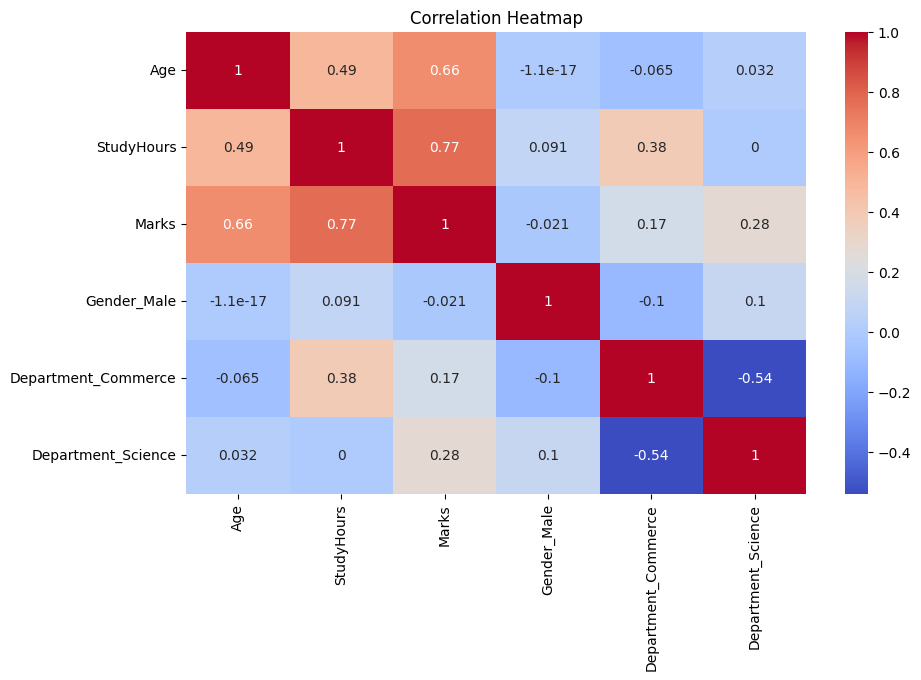

In [32]:
corr = df_scaled.corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [43]:
X = df_scaled[['StudyHours']]
y = df_scaled['Marks']


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel trained successfully!")
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)


Model trained successfully!
Slope (m): 0.7658905808400243
Intercept (c): 0.03266806340796968


In [46]:
y_pred = model.predict(X_test)

In [37]:
print("\n--- Model Performance ---")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


--- Model Performance ---
MAE: 0.30260913795848143
MSE: 0.1381146631634946
R2 Score: 0.4109847565678394


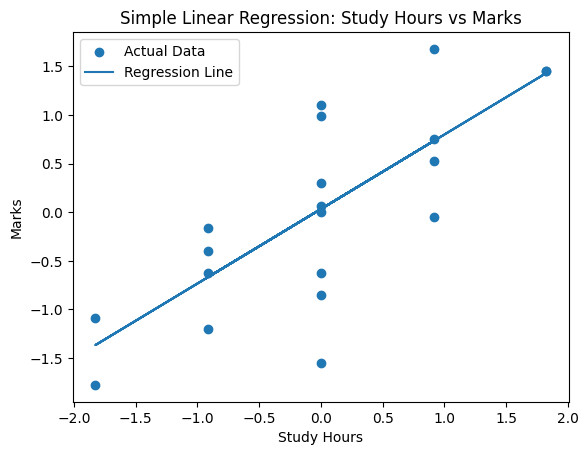

In [47]:
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Simple Linear Regression: Study Hours vs Marks")
plt.legend()
plt.show()